# 02 — Regime Analysis

Classify market regimes using macro indicators and analyze regime-conditional returns.

**4 Regimes:**
1. Risk-On Growth (VIX<20, OVX<30, 2s10s>0)
2. Inflation Shock (WTI>80th pct, Breakeven>2.5%, VIX<30)
3. Geopolitical Crisis (OVX>90th pct OR VIX>30 + BW spread>5)
4. Recession / Risk-Off (2s10s<0, VIX>25)

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath(os.path.join('..', '..')))

import pickle, numpy as np, pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from matplotlib.colors import LinearSegmentedColormap

from energy_workbook.config import ALL_TICKERS, EQUITY_TICKERS, REGIME_NAMES, RF_RATE

VIZ = os.path.abspath(os.path.join('..', 'visualization'))
DATA = os.path.abspath(os.path.join('..', 'data'))

plt.rcParams.update({
    'font.family': 'serif', 'font.size': 11, 'axes.titlesize': 14,
    'figure.facecolor': 'white', 'axes.facecolor': '#FAFAFA',
    'axes.edgecolor': '#CCCCCC', 'axes.grid': True,
    'grid.alpha': 0.3, 'legend.fontsize': 9,
})
MC_COLORS = ['#002B5C','#1A3C6E','#4A86C8','#0070C0','#C89600',
             '#E06C00','#C00000','#008000','#7030A0','#666666']
cmap_rg = LinearSegmentedColormap.from_list('rg', ['#C00000','#FFFFFF','#006100'])

def savefig(fig, name, dpi=180):
    fig.savefig(os.path.join(VIZ, name), dpi=dpi, bbox_inches='tight',
                facecolor='white', edgecolor='none')
    print(f'  saved {name}')

cache_path = os.path.abspath(os.path.join('..', '..', 'data_cache.pkl'))
with open(cache_path, 'rb') as f:
    D = pickle.load(f)
MASTER = D['master']; LOG_RET = D['log_returns']
print('Data loaded')

Data loaded


## 2.1 Regime Classification

In [2]:
vix = MASTER.get('VIX', pd.Series(dtype=float))
ovx = MASTER.get('OVX', pd.Series(dtype=float))
wti = MASTER.get('WTI', pd.Series(dtype=float))
s2s10 = MASTER.get('Spread_2s10s', pd.Series(dtype=float))
bev = MASTER.get('T10YIE', pd.Series(dtype=float))
bws = MASTER.get('Brent_WTI_Spread', pd.Series(dtype=float))

regime = pd.Series(0, index=MASTER.index, dtype=int)
for i in range(len(MASTER)):
    v = vix.iloc[i] if i < len(vix) else np.nan
    o = ovx.iloc[i] if i < len(ovx) else np.nan
    s = s2s10.iloc[i] if i < len(s2s10) else np.nan
    w = wti.iloc[i] if i < len(wti) else np.nan
    b = bev.iloc[i] if i < len(bev) else np.nan
    bw_v = bws.iloc[i] if i < len(bws) else np.nan
    if pd.isna(v):
        continue
    ovx_90 = ovx.iloc[:i+1].quantile(0.9) if i > 10 and not pd.isna(o) else 50
    wti_80 = wti.iloc[:i+1].quantile(0.8) if i > 10 and not pd.isna(w) else 80
    if (not pd.isna(o) and o > ovx_90) or (v > 30 and not pd.isna(bw_v) and bw_v > 5):
        regime.iloc[i] = 3
    elif not pd.isna(s) and s < 0 and v > 25:
        regime.iloc[i] = 4
    elif not pd.isna(w) and w > wti_80 and not pd.isna(b) and b > 2.5 and v < 30:
        regime.iloc[i] = 2
    elif v < 20 and (pd.isna(o) or o < 30) and (pd.isna(s) or s > 0):
        regime.iloc[i] = 1

regime.to_csv(os.path.join(DATA, 'regime_classification.csv'), header=['regime'])

# Distribution
print('Regime Distribution:')
for rid, rname in REGIME_NAMES.items():
    ct = (regime == rid).sum()
    print(f'  {rname}: {ct} days ({ct/len(regime)*100:.1f}%)')

Regime Distribution:
  Transition: 1429 days (78.4%)
  Risk-On Growth: 92 days (5.0%)
  Inflation Shock: 102 days (5.6%)
  Geopolitical Crisis: 156 days (8.6%)
  Recession / Risk-Off: 44 days (2.4%)


## 2.2 Regime Timeline with Oil Prices

  saved 04_regime_timeline.png


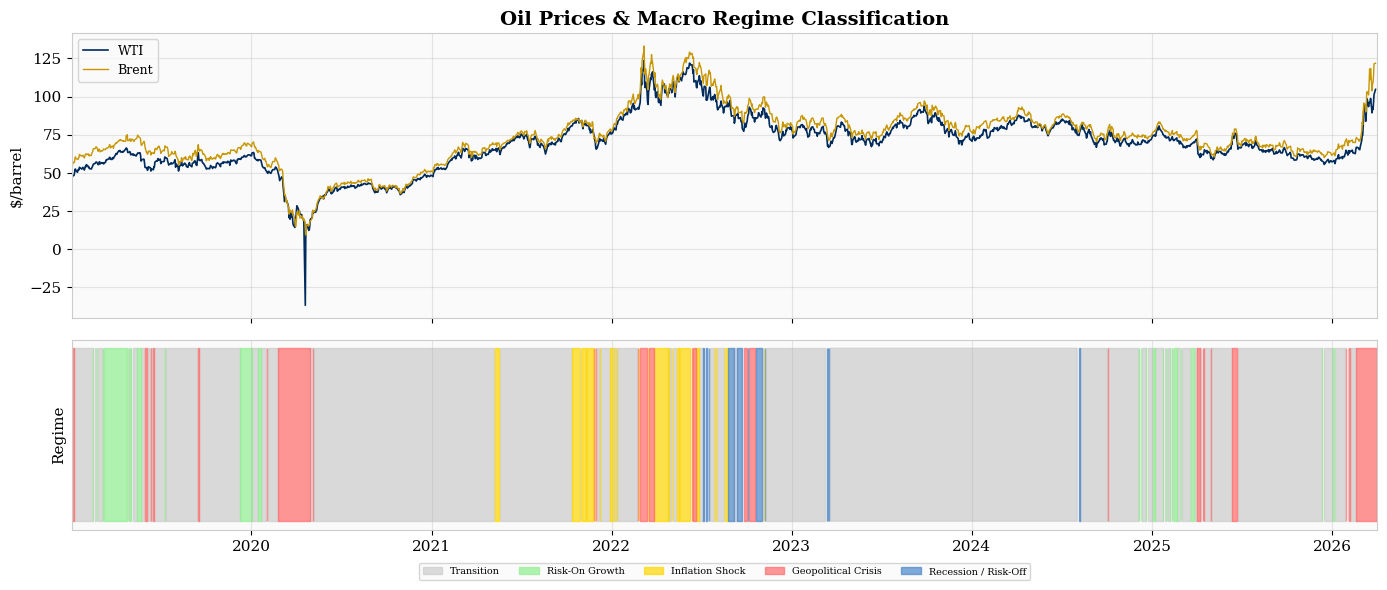

In [3]:
regime_colors_map = {0: '#CCCCCC', 1: '#90EE90', 2: '#FFD700', 3: '#FF6B6B', 4: '#4A86C8'}

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 6), height_ratios=[1.5, 1], sharex=True)

ax1.plot(wti.dropna().index, wti.dropna().values, label='WTI', color='#002B5C', linewidth=1.2)
brent = MASTER.get('Brent', pd.Series(dtype=float))
ax1.plot(brent.dropna().index, brent.dropna().values, label='Brent', color='#C89600', linewidth=1.0)
ax1.set_ylabel('$/barrel'); ax1.legend(loc='upper left', fontsize=9)
ax1.set_title('Oil Prices & Macro Regime Classification', fontweight='bold')

for rid, rname in REGIME_NAMES.items():
    mask = regime == rid
    if mask.any():
        ax2.fill_between(regime.index, 0, 1, where=mask,
                         color=regime_colors_map.get(rid, '#CCC'), alpha=0.7,
                         label=rname, step='mid')
ax2.set_yticks([]); ax2.set_ylabel('Regime')
ax2.legend(ncol=5, loc='upper center', fontsize=7, bbox_to_anchor=(0.5, -0.15))
ax2.set_xlim(MASTER.index[0], MASTER.index[-1])
fig.tight_layout()
savefig(fig, '04_regime_timeline.png')
plt.show()

## 2.3 Regime Distribution Pie Chart

  saved 13_regime_distribution.png


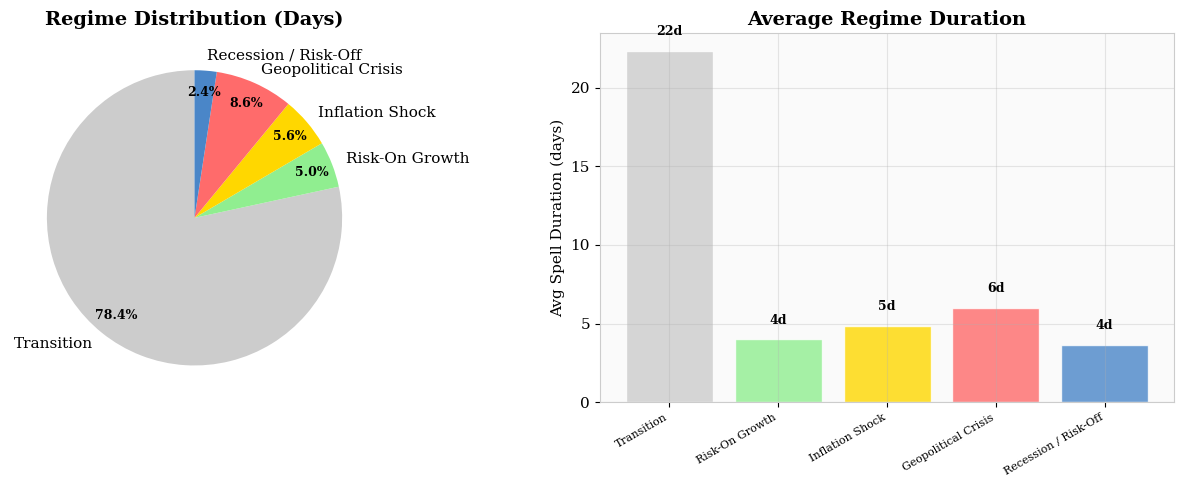

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Pie chart
ax = axes[0]
labels = [REGIME_NAMES[r] for r in sorted(REGIME_NAMES.keys())]
sizes = [(regime == r).sum() for r in sorted(REGIME_NAMES.keys())]
colors_pie = [regime_colors_map[r] for r in sorted(REGIME_NAMES.keys())]
wedges, texts, autotexts = ax.pie(sizes, labels=labels, colors=colors_pie,
                                   autopct='%1.1f%%', startangle=90, pctdistance=0.85)
for t in autotexts:
    t.set_fontsize(9); t.set_fontweight('bold')
ax.set_title('Regime Distribution (Days)', fontweight='bold')

# Regime durations
ax = axes[1]
regime_changes = regime.diff().fillna(1)
spell_lengths = []
current_regime = regime.iloc[0]
current_len = 0
for i in range(len(regime)):
    if regime.iloc[i] == current_regime:
        current_len += 1
    else:
        spell_lengths.append((current_regime, current_len))
        current_regime = regime.iloc[i]
        current_len = 1
spell_lengths.append((current_regime, current_len))

for rid in sorted(REGIME_NAMES.keys()):
    durations = [l for r, l in spell_lengths if r == rid]
    if durations:
        ax.bar(REGIME_NAMES[rid], np.mean(durations), color=regime_colors_map[rid],
               edgecolor='white', alpha=0.8)
        ax.text(list(REGIME_NAMES.values()).index(REGIME_NAMES[rid]),
                np.mean(durations) + 1, f'{np.mean(durations):.0f}d',
                ha='center', fontsize=9, fontweight='bold')
ax.set_ylabel('Avg Spell Duration (days)')
ax.set_title('Average Regime Duration', fontweight='bold')
plt.setp(ax.get_xticklabels(), rotation=30, ha='right', fontsize=8)

fig.tight_layout()
savefig(fig, '13_regime_distribution.png')
plt.show()

## 2.4 Regime-Conditional Returns

In [5]:
regime_cond = {}
for rid in [1, 2, 3, 4]:
    mask = regime == rid
    if mask.sum() > 10:
        regime_cond[REGIME_NAMES[rid]] = {}
        for t in ALL_TICKERS:
            r = LOG_RET.get(t, pd.Series(dtype=float))
            rm = r[mask].dropna()
            if len(rm) > 5:
                regime_cond[REGIME_NAMES[rid]][t] = dict(
                    ann_ret=float(rm.mean() * 252 * 100),
                    ann_vol=float(rm.std() * np.sqrt(252) * 100),
                )

# Export
for rname, data in regime_cond.items():
    fname = f'regime_cond_{rname.replace(" ","_").replace("/","_")}.csv'
    pd.DataFrame(data).T.to_csv(os.path.join(DATA, fname))

# Display table
cond_table = {}
for rname, data in regime_cond.items():
    for t, vals in data.items():
        if t not in cond_table:
            cond_table[t] = {}
        cond_table[t][f'{rname} (Ann Ret %)'] = f"{vals['ann_ret']:.1f}"
        cond_table[t][f'{rname} (Ann Vol %)'] = f"{vals['ann_vol']:.1f}"
pd.DataFrame(cond_table).T

,Risk-On Growth (Ann Ret %),Risk-On Growth (Ann Vol %),Inflation Shock (Ann Ret %),Inflation Shock (Ann Vol %),Geopolitical Crisis (Ann Ret %),Geopolitical Crisis (Ann Vol %),Recession / Risk-Off (Ann Ret %),Recession / Risk-Off (Ann Vol %)
XOM,24.0,15.4,110.9,31.6,-15.8,57.0,-91.3,34.9
CVX,39.1,20.4,86.1,29.8,5.1,72.7,-125.8,30.9
COP,31.1,20.8,108.3,36.7,-48.6,84.7,-114.8,44.7
OXY,10.2,27.0,90.8,54.7,-99.5,131.9,-196.6,43.0
LNG,16.9,22.7,50.0,30.9,35.7,66.7,-92.4,43.5
VG,89.8,62.6,NaN,NaN,164.5,104.2,NaN,NaN
FRO,54.5,47.5,35.3,58.6,2.3,89.7,-24.5,55.4
STNG,39.3,39.2,111.1,51.5,61.8,97.4,-98.2,63.7
ET,31.1,20.3,82.6,31.0,-98.3,76.4,-147.5,38.1
BIL,3.1,0.2,0.4,0.2,2.0,0.2,3.4,0.3


## 2.5 Regime-Conditional Volatility Comparison

  saved 29_regime_conditional_vol.png


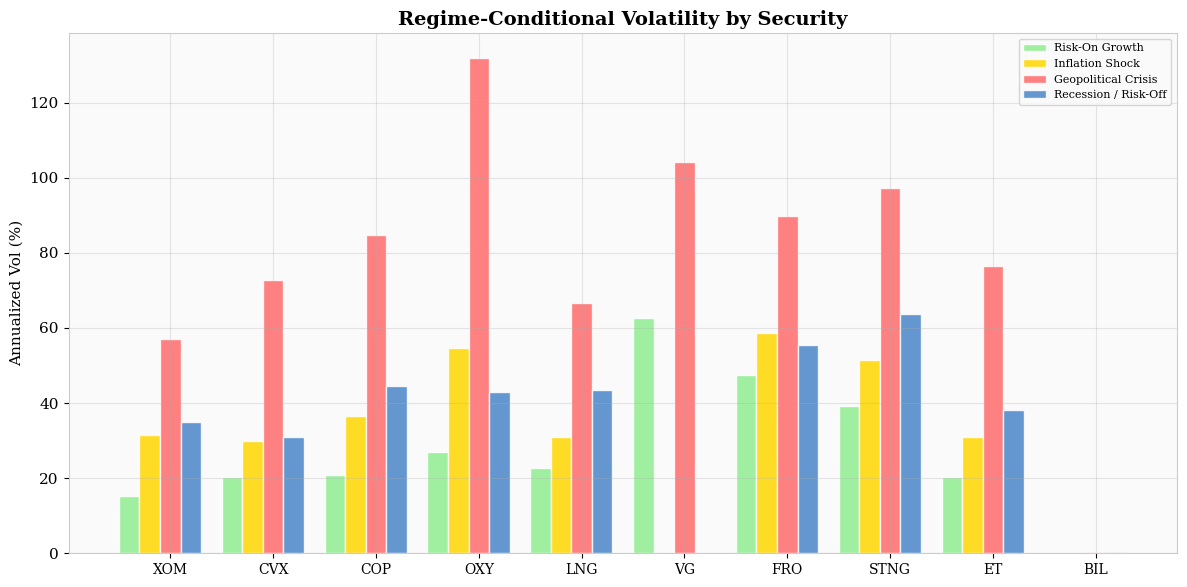

In [6]:
fig, ax = plt.subplots(figsize=(12, 6))
x = np.arange(len(ALL_TICKERS))
w = 0.2
regime_list = [r for r in [1,2,3,4] if REGIME_NAMES[r] in regime_cond]
for j, rid in enumerate(regime_list):
    rname = REGIME_NAMES[rid]
    vols = [regime_cond[rname].get(t, {}).get('ann_vol', 0) for t in ALL_TICKERS]
    ax.bar(x + j*w - len(regime_list)*w/2, vols, w,
           label=rname, color=regime_colors_map[rid], edgecolor='white', alpha=0.85)

ax.set_xticks(x); ax.set_xticklabels(ALL_TICKERS, fontsize=10)
ax.set_ylabel('Annualized Vol (%)')
ax.set_title('Regime-Conditional Volatility by Security', fontweight='bold')
ax.legend(fontsize=8)
fig.tight_layout()
savefig(fig, '29_regime_conditional_vol.png')
plt.show()